# CZ-stack / HCR Co-registration Example

Demonstrates how to load the `czstack_hcr_coreg` derived asset from the
ophys-mfish-dataset-catalog and work with the co-registration match table
and CZ-stack cell centroids.

The asset has two files:
- `{mouse_id}_coreg_table.csv` — `czstack_id` ↔ `hcr_id` match pairs
- `{mouse_id}_*_czstack_cell_centroids.csv` — CZ-stack cell centroid coordinates

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from aind_hcr_data_loader import get_hcr_dataset_pairwise

%load_ext autoreload
%autoreload 2

DATA_DIR = Path('/root/capsule/data')

## Load dataset (auto-attaches coreg asset from catalog record)

In [2]:
dataset, pw_ds, spots = get_hcr_dataset_pairwise(
    mouse_id="782149",
    data_dir=DATA_DIR,
    load_spots=False,
)
print(dataset)
print(f"\nCoreg files: {dataset.czstack_coreg_files}")

  [rounds.R1]  HCR_782149_2025-11-05_13-00-00_processed_2025-11-10_20-37-29  →  ✓ attached
  [rounds.R2]  HCR_782149_2025-11-12_13-00-00_processed_2025-11-13_22-04-32  →  ✓ attached
  [rounds.R3]  HCR_782149_2025-11-19_13-00-00_processed_2025-11-21_01-27-24  →  ✓ attached
  [rounds.R4]  HCR_782149_2025-12-04_13-00-00_processed_2025-12-05_22-31-35  →  ✓ attached
  [rounds.R5]  HCR_782149_2025-12-11_13-00-00_processed_2025-12-12_23-45-26  →  ✓ attached
  [derived_assets.roi_shape_metrics]  HCR_782149_2025-11-05_13-00-00_roi-shape-metrics  →  ✓ attached
  [derived_assets.cell_typing]  HCR_782149_cell-typing_2026-03-08_12-00-00  →  ✓ attached
  [derived_assets.pairwise_unmixing]  HCR_782149_pairwise-unmixing_2026-05-23_01-29-46  →  ✓ attached
  [derived_assets.czstack_hcr_coreg]  782149_2025-05-01_ctl-czstack-hcr-coreg_2026-03-03_00-00-00  →  ✓ attached
[DEBUG get_spot_files] key=R1 round_num=1
[DEBUG get_spot_files] folder_path=/root/capsule/data/HCR_782149_2025-11-05_13-00-00_processed_2

/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2555: UserWarning: [get_spot_files] R1: no unmixed_spots_R1*.pkl found; falling back to R-1 file: unmixed_spots_R-1_minDist_3.pkl
  _warnings.warn(
/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2564: UserWarning: [get_spot_files] R1: no mixed_spots_R1.pkl found; falling back to R-1 file: mixed_spots_R-1.pkl
  _warnings.warn(


[DEBUG get_spot_files] .pkl files in folder: ['unmixed_spots_R3_minDist_3.pkl', 'mixed_spots_R3.pkl', 'unmixed_spots_R-1_minDist_3.pkl', 'mixed_spots_R-1.pkl']
[DEBUG get_spot_files] unmixed_spots=/root/capsule/data/HCR_782149_2025-11-19_13-00-00_processed_2025-11-21_01-27-24/image_spot_spectral_unmixing/unmixed_spots_R3_minDist_3.pkl  mixed_spots=/root/capsule/data/HCR_782149_2025-11-19_13-00-00_processed_2025-11-21_01-27-24/image_spot_spectral_unmixing/mixed_spots_R3.pkl
[DEBUG get_spot_files] key=R4 round_num=4
[DEBUG get_spot_files] folder_path=/root/capsule/data/HCR_782149_2025-12-04_13-00-00_processed_2025-12-05_22-31-35/image_spot_spectral_unmixing exists=True
[DEBUG get_spot_files] .pkl files in folder: ['unmixed_spots_R-1_minDist_3.pkl', 'mixed_spots_R-1.pkl', 'mixed_spots_R4.pkl', 'unmixed_spots_R4_minDist_3.pkl']
[DEBUG get_spot_files] unmixed_spots=/root/capsule/data/HCR_782149_2025-12-04_13-00-00_processed_2025-12-05_22-31-35/image_spot_spectral_unmixing/unmixed_spots_R4_m

## Load the co-registration match table

`czstack_id` → CZ-stack cell ID, `hcr_id` → HCR cell ID (matches `cell_id` in spots/CxG).

In [3]:
coreg_df = dataset.load_coreg_table()
print(f"Matched cells: {len(coreg_df)}")
coreg_df.head()

Matched cells: 303


,czstack_id,hcr_id
0,5,6711
1,14,5459
2,23,3084
3,38,5099
4,52,6282


## Load the CZ-stack cell centroids

In [4]:
czstack_centroids = pd.read_csv(dataset.czstack_coreg_files.czstack_cell_centroids)
print(f"CZ-stack cells: {len(czstack_centroids)}")
czstack_centroids.head()

CZ-stack cells: 894


,czstack_cell_id,czstack_z,czstack_y,czstack_x
0,1,21.516636,495.519626,402.256075
1,2,31.620602,401.177930,372.028853
2,3,26.780228,484.703414,360.098862
3,4,26.711964,169.345904,418.250325
4,5,58.035731,240.496863,244.541231


## Join coreg table with HCR cell info

In [5]:
# Load HCR cell info (volume, centroid) for R1
hcr_cell_info = dataset.get_cell_info(source="mixed_cxg")

# Merge on hcr_id → cell_id
coreg_merged = coreg_df.merge(
    hcr_cell_info[["cell_id", "volume", "x_centroid", "y_centroid", "z_centroid"]],
    left_on="hcr_id",
    right_on="cell_id",
    how="inner",
)

# Also join CZ-stack centroids
coreg_merged = coreg_merged.merge(
    czstack_centroids,
    left_on="czstack_id",
    right_on="czstack_cell_id",
    how="inner",
    suffixes=("_hcr", "_czstack"),
)

print(f"Matched cells with full info: {len(coreg_merged)}")
coreg_merged.head()

/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:464: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(


Loading mixed cxg for round R1


/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:464: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(


Loading mixed cxg for round R2


/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:464: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(


...

/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:464: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(


Loading mixed cxg for round R4


/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:464: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(


Loading mixed cxg for round R5
Matched cells with full info: 303


,czstack_id,hcr_id,cell_id,volume,x_centroid,y_centroid,z_centroid,czstack_cell_id,czstack_z,czstack_y,czstack_x
0,5,6711,6711,92800.0,4792,5648,440,5,58.035731,240.496863,244.541231
1,14,5459,5459,315008.0,3600,7002,420,14,34.039887,18.903266,457.089824
2,23,3084,3084,91104.0,3364,4522,335,23,37.069260,400.334158,462.540364
3,38,5099,5099,73488.0,3180,6660,403,38,40.686514,76.041966,502.707676
4,52,6282,6282,164368.0,5012,4884,430,52,50.288091,355.217851,208.881172


## Quick QC: HCR vs CZ-stack centroid positions

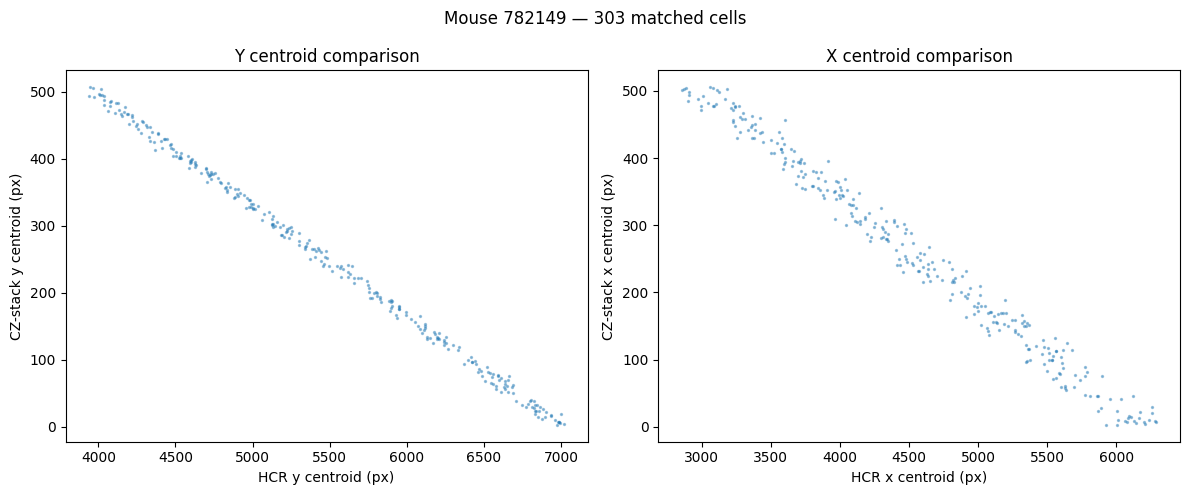

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    coreg_merged["y_centroid"],
    coreg_merged["czstack_y"],
    s=2, alpha=0.4,
)
axes[0].set_xlabel("HCR y centroid (px)")
axes[0].set_ylabel("CZ-stack y centroid (px)")
axes[0].set_title("Y centroid comparison")

axes[1].scatter(
    coreg_merged["x_centroid"],
    coreg_merged["czstack_x"],
    s=2, alpha=0.4,
)
axes[1].set_xlabel("HCR x centroid (px)")
axes[1].set_ylabel("CZ-stack x centroid (px)")
axes[1].set_title("X centroid comparison")

plt.suptitle(f"Mouse 782149 — {len(coreg_merged)} matched cells")
plt.tight_layout()
plt.show()

In [9]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"
import plotly.graph_objects as go



hcr_trace = go.Scatter3d(
    x=coreg_merged["x_centroid"],
    y=coreg_merged["y_centroid"],
    z=coreg_merged["z_centroid"],
    mode="markers",
    name="HCR cells",
    marker=dict(size=3, color="steelblue", opacity=0.7),
    text=coreg_merged["hcr_id"].astype(str),
    hovertemplate="HCR cell_id: %{text}<br>x: %{x:.1f} y: %{y:.1f} z: %{z:.1f}<extra></extra>",
    )

czstack_trace = go.Scatter3d(
    x=coreg_merged["czstack_x"],
    y=coreg_merged["czstack_y"],
    z=coreg_merged["czstack_z"],
    mode="markers",
    name="CZ-stack cells",
    marker=dict(size=3, color="darkorange", opacity=0.7),
    text=coreg_merged["czstack_id"].astype(str),
    hovertemplate="CZ-stack id: %{text}<br>x: %{x:.1f} y: %{y:.1f} z: %{z:.1f}<extra></extra>",
    )


line_x, line_y, line_z = [], [], []
for _, row in coreg_merged.iterrows():
    line_x += [row["x_centroid"], row["czstack_x"], None]
    line_y += [row["y_centroid"], row["czstack_y"], None]
    line_z += [row["z_centroid"], row["czstack_z"], None]

lines_trace = go.Scatter3d(
x=line_x, y=line_y, z=line_z,
mode="lines",
name="match pairs",
line=dict(color="gray", width=1),
opacity=0.3,
hoverinfo="skip",
)

fig3d = go.Figure(data=[hcr_trace, czstack_trace, lines_trace])
fig3d.update_layout(
title=f"Mouse 782149 — {len(coreg_merged)} matched cells",
scene=dict(
xaxis_title="x (px)",
yaxis_title="y (px)",
zaxis_title="z (px)",
aspectmode="data",
),
legend=dict(x=0, y=1),
margin=dict(l=0, r=0, b=0, t=40),
height=650,
)
fig3d.show()